In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import numpy as np
import pickle
import seaborn as sns
from tqdm import tqdm
from skimage.transform import rotate
import os

In [2]:
root_path = "/home/stefan/ioai-prep/kits/ojia-2026/perry"
seed = 42

# Data

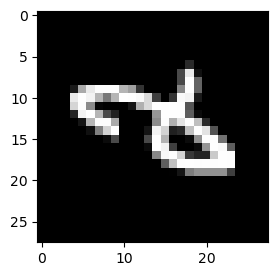

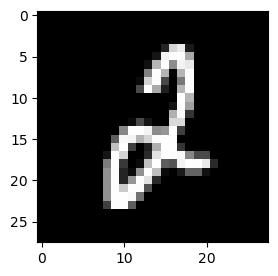

In [3]:
sample_idx = 2
sample_img = np.load(f"{root_path}/test_data/subtask1/{sample_idx}.npy")

plt.figure(figsize=(3, 3))
plt.imshow(sample_img, cmap="gray")

plt.figure(figsize=(3, 3))
plt.imshow(rotate(sample_img, 270), cmap="gray")

In [23]:
sample_img.ravel().shape

(784,)

In [4]:
with open(f"{root_path}/test_data/doof_oracle.pkl", "rb") as f:
    oracle = pickle.load(f)
oracle

/home/stefan/.local/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

array([[2.21729200e-02, 5.65350076e-06, 9.77821426e-01]])

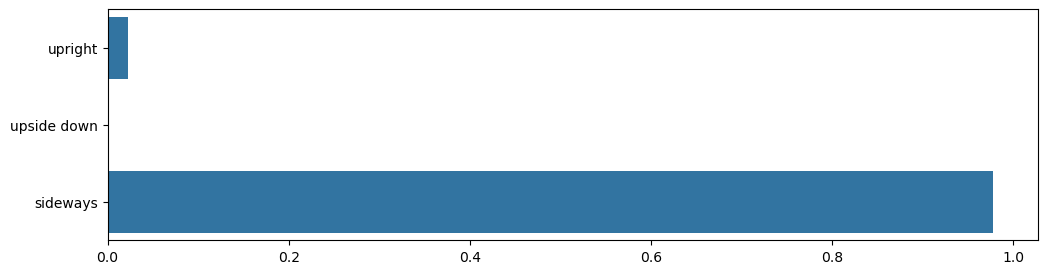

In [5]:
prob = oracle.predict_proba(sample_img.ravel().reshape(1, -1))
plt.figure(figsize=(12,3))
sns.barplot(x=prob.flatten(), y=["upright", "upside down", "sideways"])
prob

# Subtask 1

In [6]:
prep = lambda img: img.ravel().reshape(1, -1)

In [7]:
def do_subtask1(img):
    rot = oracle.predict_proba(prep(img))
    ans = np.argmax(rot)
    if ans < 2:
        # 0 = 0deg, 2 = 180deg
        return 0 if ans == 0 else 2
    
    img = rotate(img, 270)
    if oracle.predict(prep(img)) == 1:
        return 3 # 270deg
    return 1 # 90deg

In [8]:
do_subtask1(sample_img)

1

In [ ]:
nr_img = len(os.listdir(f"{root_path}/test_data/subtask1"))
images = list(range(nr_img))
subtask1 = []

for image_filename in tqdm(images):
    img = np.load(f"{root_path}/test_data/subtask1/{image_filename}.npy")
    
    subtask1.append(do_subtask1(img))

subtask1 = np.array(subtask1)

100%|██████████| 5000/5000 [00:14<00:00, 340.87it/s] 


In [10]:
np.unique(subtask1, return_counts=True)

(array([0, 1, 2, 3]), array([1258, 1242, 1304, 1196]))

<Axes: ylabel='Count'>

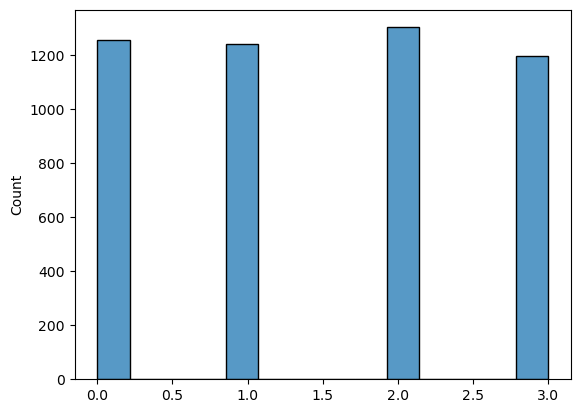

In [11]:
sns.histplot(subtask1)

# Subtask 2

In [ ]:
def do_subtask2(img):
    # search for the "undo" rotation
    angles_8 = [0, 45, 90, 135, 180, 225, 270, 315]
    best_score = -np.inf
    best_alpha = 0
    best_class = 0 # 0 for up, 1 for down

    for alpha in angles_8:
        # Rotate by candidate angle alpha (remembering the secret background!)
        img_a = rotate(
            img, alpha, resize=False, order=1, mode="constant", cval=-0.25
        ).astype(np.float32)
        p = oracle.predict_proba(img_a.reshape(1, -1))[0]

        # How confident is it in up or down?
        score = max(p[0], p[1])
        c_ud = 0 if p[0] > p[1] else 1

        if score > best_score:
            best_score = score
            best_alpha = alpha
            best_class = c_ud

    # Reverse engineer the original angle
    if best_class == 0: # It looked Upright
        return (-best_alpha) % 360
    else:               # It looked Upside-Down
        return (180 - best_alpha) % 360

In [13]:
nr_img = len(os.listdir(f"{root_path}/test_data/subtask2"))
images = list(range(nr_img))
subtask2 = []

for image_filename in tqdm(images):
    img = np.load(f"{root_path}/test_data/subtask2/{image_filename}.npy")

    subtask2.append(do_subtask2(img) // 45)

subtask2 = np.array(subtask2)

100%|██████████| 5000/5000 [00:10<00:00, 461.16it/s]


<Axes: ylabel='Count'>

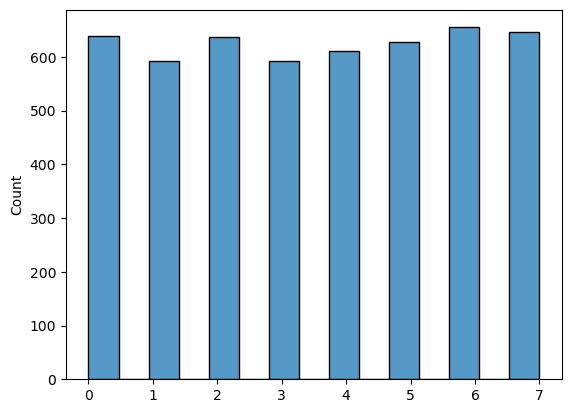

In [14]:
sns.histplot(subtask2)

# Subtask 3

In [15]:
def permute_probs_180(p):
    # Under 180 rotation, P_Up and P_Down swap. P_Sideways stays the same.
    return np.array([p[1], p[0], p[2]])


def do_subtask3(img):
    # Original prediction
    p0 = oracle.predict_proba(img.reshape(1, -1))[0]

    # 1. Calculate Margin (Top 1 - Top 2)
    sorted_p = np.sort(p0)
    margin = sorted_p[-1] - sorted_p[-2]

    # 2. Calculate 180-Degree Consistency Error (e180)
    img180 = rotate(img, 180)
    p180 = oracle.predict_proba(img180.reshape(1, -1))[0]

    p_expected = permute_probs_180(p0)
    e180 = np.sum(np.abs(p180 - p_expected))

    wrongness_score = (1.0 - margin) + 0.3 * e180
    return wrongness_score > 0.35

In [16]:
nr_img = len(os.listdir(f"{root_path}/test_data/subtask3"))
images = list(range(nr_img))
subtask3 = []

for image_filename in tqdm(images):
    img = np.load(f"{root_path}/test_data/subtask3/{image_filename}.npy")

    subtask3.append(do_subtask3(img))

subtask3 = np.array(subtask3)

100%|██████████| 5000/5000 [00:03<00:00, 1618.75it/s]


In [17]:
np.unique(subtask3, return_counts=True)

(array([False,  True]), array([4399,  601]))

# Submission

In [18]:
def build_sub(sid, ans):
    return pd.DataFrame({
        "datapointID": list(range(len(ans))),
        "subtaskID": sid,
        "answer": ans
    })

subtasks = [
    (1, subtask1),
    (2, subtask2),
    (3, subtask3),
]

submission = pd.concat([build_sub(sid, ans) for sid, ans in subtasks])

In [19]:
submission.head()

,datapointID,subtaskID,answer
0,0,1,1
1,1,1,0
2,2,1,1
3,3,1,2
4,4,1,2


In [20]:
submission.to_csv(f"{root_path}/submission.csv", index=False)